# 04 — Machine Learning

Notebook dedicato al preprocessing finale, alla selezione delle feature e all'addestramento dei modelli.

**Sprint 3 | Settimana 3**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sys.path.append(os.path.abspath(".."))

df = pd.read_csv(os.path.abspath(os.path.join("..", "data", "processed", "data_clean.csv")))

sns.set_theme(style="whitegrid")
print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")

Dataset caricato: 7043 righe, 37 colonne


## Rimozione variabili ridondanti

Dall'analisi della matrice di correlazione (US-10) emergono 3 coppie dove una variabile
è sostanzialmente un duplicato dell'altra. Le rimuoviamo prima di qualsiasi modellazione.

| Rimossa | Mantenuta | Correlazione | Motivazione |
|---|---|---|---|
| `partner` | `married` | 1.000 | Identiche — stessa informazione codificata due volte |
| `dependents` | `num_dependents` | 0.888 | Binaria vs conteggio — `num_dependents` è più informativa |
| `total_charges` | `total_revenue` | 0.972 | `total_revenue` include già i rimborsi — più completa |

In [36]:
from src.preprocessing import drop_redundant_features

df = drop_redundant_features(df)
print(f"Colonne dopo rimozione ridondanti: {df.shape[1]}")
print(f"Colonne rimosse: partner, dependents, total_charges")

Colonne dopo rimozione ridondanti: 34
Colonne rimosse: partner, dependents, total_charges


## US-15 · Preprocessing delle Variabili

Le variabili vengono classificate in tre tipi e trattate con trasformazioni diverse:
- **Numeriche continue** → standardizzazione (`StandardScaler`)
- **Categoriche nominali** → One-Hot Encoding (`OneHotEncoder`)
- **Binarie (0/1)** → nessuna trasformazione necessaria

### Classificazione delle variabili

In [37]:
# Separazione target
y = df["churn"]
X = df.drop(columns=["churn"])

# Variabili categoriche nominali — richiedono One-Hot Encoding
cat_cols = ["contract", "internet_type", "payment_method", "offer", "gender"]

# Variabili binarie (già 0/1) — nessuna trasformazione
# partner e dependents già rimossi nella sezione precedente (ridondanti con married e num_dependents)
binary_cols = [
    "device_protection_plan", "internet_service", "married",
    "multiple_lines", "online_backup", "online_security", "paperless_billing",
    "phone_service", "premium_tech_support", "referred_a_friend",
    "senior_citizen", "streaming_movies", "streaming_music", "streaming_tv",
    "unlimited_data"
]

# Variabili numeriche continue — richiedono StandardScaler
# total_charges già rimossa nella sezione precedente (ridondante con total_revenue)
num_cols = [col for col in X.columns if col not in cat_cols + binary_cols]

print(f"Numeriche continue ({len(num_cols)}): {num_cols}")
print(f"\nCategoriche nominali ({len(cat_cols)}): {cat_cols}")
print(f"\nBinarie ({len(binary_cols)}): {binary_cols}")

Numeriche continue (13): ['age', 'avg_monthly_gb_download', 'avg_monthly_ld_charges', 'cltv', 'monthly_charge', 'num_dependents', 'num_referrals', 'population', 'tenure_months', 'total_extra_data_charges', 'total_ld_charges', 'total_refunds', 'total_revenue']

Categoriche nominali (5): ['contract', 'internet_type', 'payment_method', 'offer', 'gender']

Binarie (15): ['device_protection_plan', 'internet_service', 'married', 'multiple_lines', 'online_backup', 'online_security', 'paperless_billing', 'phone_service', 'premium_tech_support', 'referred_a_friend', 'senior_citizen', 'streaming_movies', 'streaming_music', 'streaming_tv', 'unlimited_data']


### Pipeline di preprocessing con ColumnTransformer

`ColumnTransformer` applica trasformazioni diverse a colonne diverse in un unico oggetto.
`Pipeline` concatena preprocessing e modello — garantisce che la standardizzazione
venga calcolata **solo sul train set** e poi applicata al test, evitando data leakage.

In [38]:
from src.preprocessing import build_preprocessor

preprocessor = build_preprocessor(num_cols, cat_cols, binary_cols)
print("✅ Preprocessor costruito")
print(preprocessor)

✅ Preprocessor costruito
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'avg_monthly_gb_download',
                                  'avg_monthly_ld_charges', 'cltv',
                                  'monthly_charge', 'num_dependents',
                                  'num_referrals', 'population',
                                  'tenure_months', 'total_extra_data_charges',
                                  'total_ld_charges', 'total_refunds',
                                  'total_revenue']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['co...t', 'internet_type', 'payment_method',
                                  'offer', 'gender']),
                                ('bin', 'passthrough',
                                 ['device_protection_plan', 'internet_ser

### Osservazioni US-15

| Tipo | N. variabili | Trasformazione | Motivazione |
|---|---|---|---|
| Numeriche continue | 13 | `StandardScaler` | Portare tutte le variabili sulla stessa scala — obbligatorio per LR e MLP |
| Categoriche nominali | 5 | `OneHotEncoder` | Convertire le categorie in colonne 0/1 — i modelli non interpretano stringhe |
| Binarie | 15 | Nessuna | Già in formato 0/1 |

**Nota sul data leakage nella pipeline**: usando `Pipeline(preprocessor, modello)` e addestrando
solo sul train set, lo scaler impara media e deviazione standard esclusivamente dai dati di train.
Quando trasformiamo il test set usiamo i parametri del train — mai i dati di test.

### US-16: Split Train/Test e Baseline

Il dataset viene diviso in due porzioni distinte: **80% per il training** (≈5.634 clienti)
e **20% per il test** (≈1.409 clienti). La divisione è **stratificata** sulla variabile target,
garantendo che la proporzione 73.5% / 26.5% tra clienti rimasti e churned sia mantenuta
identica in entrambe le porzioni — evitando che lo split casuale concentri
per caso troppi churned in una sola parte.

Prima di allenare qualsiasi modello, stabiliamo una **baseline**: le performance
di un classificatore banale che predice sempre la classe maggioritaria ("rimasto").
Questo valore di riferimento quantifica il punto di partenza — qualsiasi modello
che non lo supera non aggiunge valore reale rispetto a non fare nulla.

In [39]:
from sklearn.model_selection import train_test_split

# Split 80/20 stratificato sulla variabile target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train set: {X_train.shape[0]} clienti ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} clienti ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDimensioni X_train: {X_train.shape}")
print(f"Dimensioni X_test:  {X_test.shape}")

Train set: 5634 clienti (80.0%)
Test set:  1409 clienti (20.0%)

Dimensioni X_train: (5634, 33)
Dimensioni X_test:  (1409, 33)


In [40]:
# Verifica della stratificazione — la proporzione churned/non-churned
# deve essere identica in train e test rispetto al dataset originale
print("Distribuzione classe target:")
print(f"\n{'Set':<10} {'Rimasti (0)':>12} {'Churned (1)':>12}")
print("-" * 36)

for nome, y_set in [("Originale", y), ("Train", y_train), ("Test", y_test)]:
    pct_0 = (y_set == 0).sum() / len(y_set) * 100
    pct_1 = (y_set == 1).sum() / len(y_set) * 100
    print(f"{nome:<10} {pct_0:>11.1f}% {pct_1:>11.1f}%")

Distribuzione classe target:

Set         Rimasti (0)  Churned (1)
------------------------------------
Originale         73.5%        26.5%
Train             73.5%        26.5%
Test              73.5%        26.5%


### Osservazioni — Split Train/Test

Split eseguito correttamente: 5.634 clienti in train, 1.409 in test.
La stratificazione è verificata — la proporzione 73.5% / 26.5% è identica
in tutti e tre i set. I dati sono pronti per la fase di baseline.

In [41]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# Baseline: classificatore che predice sempre la classe maggioritaria ("rimasto")
# Stabilisce il punto di partenza minimo che ogni modello deve superare
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# Valutazione con F1-Score, Precision e Recall — non solo Accuracy
print("=== BASELINE — DummyClassifier ===\n")
print(classification_report(y_test, y_pred_dummy, 
                             target_names=["Rimasto (0)", "Churned (1)"],
                             zero_division=0))

=== BASELINE — DummyClassifier ===

              precision    recall  f1-score   support

 Rimasto (0)       0.73      1.00      0.85      1035
 Churned (1)       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



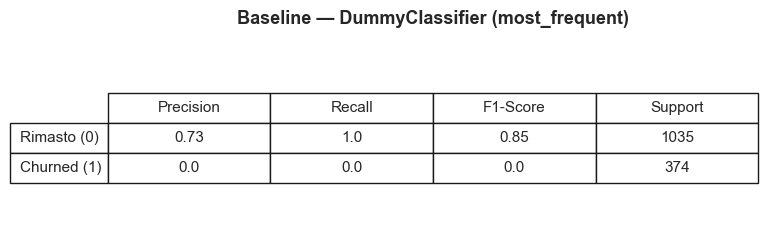

✅ Figura salvata in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\16_baseline_dummyclassifier.png


In [43]:
# Estrazione del classification report come dizionario per la visualizzazione
report = classification_report(y_test, y_pred_dummy,
                                target_names=["Rimasto (0)", "Churned (1)"],
                                zero_division=0,
                                output_dict=True)

# Costruzione della tabella — escludiamo le righe di aggregazione
df_report = pd.DataFrame(report).T.loc[["Rimasto (0)", "Churned (1)"],
                                        ["precision", "recall", "f1-score", "support"]]
df_report["support"] = df_report["support"].astype(int).astype(str)

# Visualizzazione come tabella grafica e salvataggio per la presentazione
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis("off")

table = ax.table(
    cellText=df_report.round(2).values,
    rowLabels=df_report.index,
    colLabels=["Precision", "Recall", "F1-Score", "Support"],
    cellLoc="center",
    loc="center"
)
table.scale(1.2, 2)
table.auto_set_font_size(False)
table.set_fontsize(11)

plt.title("Baseline — DummyClassifier (most_frequent)",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "16_baseline_dummyclassifier.png"))
plt.savefig(figures_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figura salvata in: {figures_path}")

### Osservazioni — Baseline DummyClassifier

Il **DummyClassifier** è un classificatore banale che non analizza nessuna feature:
predice sempre la classe maggioritaria, in questo caso "rimasto". Viene usato come
punto di partenza per misurare il reale contributo dei modelli successivi.

**Risultati:**

| Metrica | Rimasto (0) | Churned (1) |
|---|---|---|
| Precision | 0.73 | 0.00 |
| Recall | 1.00 | 0.00 |
| F1-Score | 0.85 | 0.00 |

**Accuracy: 73%** — un valore apparentemente accettabile, ma che riflette
semplicemente la proporzione delle classi nel dataset. Un modello che ignora
completamente i dati ottiene il 73% di accuracy per costruzione.

**F1-Score e Recall churned: 0.00** — il classificatore non identifica
nessuno dei 374 clienti a rischio nel test set. Dal punto di vista del business,
questo equivale a non fare nulla: zero interventi di retention, zero clienti salvati.

Questi risultati confermano che l'Accuracy non è una metrica adeguata
su dataset sbilanciati e motivano l'adozione di modelli più sofisticati,
valutati principalmente tramite **F1-Score sulla classe churned**.

## US-17 · Selezione Feature con SelectKBest e Logistic Regression

Obiettivo: identificare le **10 variabili più informative** per la predizione del churn
e allenare su di esse una **Logistic Regression** — un modello semplice, interpretabile
e spiegabile al management.

**`SelectKBest` con `f_classif`** calcola un F-score per ogni feature misurando
quanto ogni variabile discrimina staticamente le due classi (churned vs rimasto).
Le variabili con F-score più alto sono le più predittive.

La pipeline finale segue lo schema:
`StandardScaler / OHE → SelectKBest(k=10) → LogisticRegression`

/var/folders/d7/fjrcsm5s3978dxn1948xk1tm0000gn/T/ipykernel_5585/3765901406.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="score", y="feature", palette="Blues_r", orient="h", ax=ax)


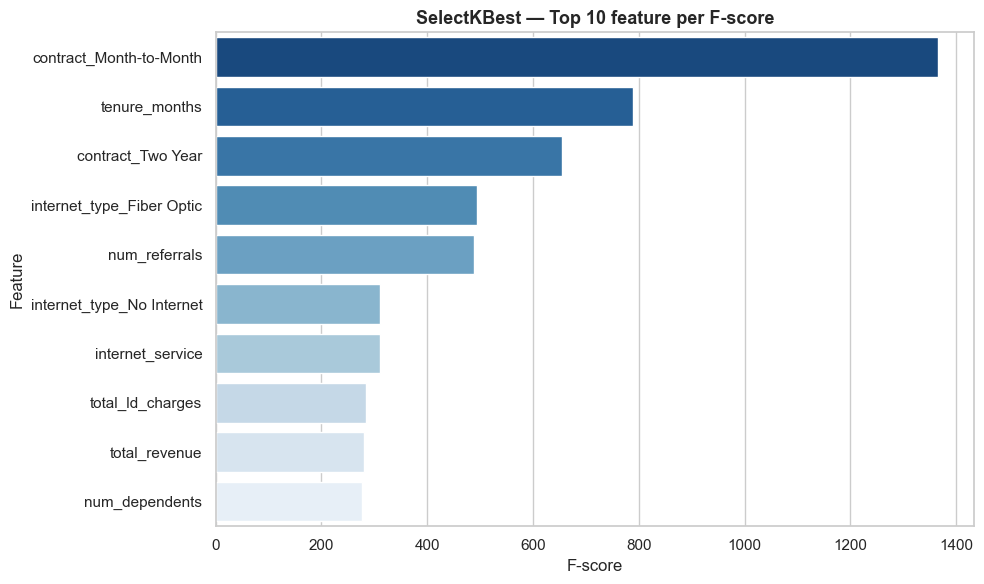

✅ Figura salvata in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/17_selectkbest_top10.png

Top 10 feature selezionate:
                  feature       score
  contract_Month-to-Month 1365.417419
            tenure_months  789.093992
        contract_Two Year  654.714541
internet_type_Fiber Optic  494.599305
            num_referrals  489.366585
internet_type_No Internet  311.736079
         internet_service  311.736079
         total_ld_charges  285.192006
            total_revenue  280.433158
           num_dependents  276.471107


In [11]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

# Fit preprocessor + SelectKBest per estrarre gli score su tutte le feature
selector_pipe = Pipeline([
    ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
    ("selector", SelectKBest(f_classif, k=10))
])
selector_pipe.fit(X_train, y_train)

# Nomi feature dopo ColumnTransformer (OHE espande le categoriche)
feature_names_raw = selector_pipe.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names_raw]

# Score F per ogni feature — ordinati per valore decrescente
score_df = pd.DataFrame({"feature": feature_names, "score": selector_pipe.named_steps["selector"].scores_})
score_df = score_df.sort_values("score", ascending=False)

# Visualizzazione top 10
top10 = score_df.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10, x="score", y="feature", palette="Blues_r", orient="h", ax=ax)
ax.set_title("SelectKBest — Top 10 feature per F-score", fontsize=13, fontweight="bold")
ax.set_xlabel("F-score")
ax.set_ylabel("Feature")
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "17_selectkbest_top10.png"))
plt.savefig(figures_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figura salvata in: {figures_path}")
print(f"\nTop 10 feature selezionate:\n{top10.to_string(index=False)}")

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Pipeline completa: preprocessing → selezione top 10 → Logistic Regression
pipeline_lr = Pipeline([
    ("preprocessor", build_preprocessor(num_cols, cat_cols, binary_cols)),
    ("selector", SelectKBest(f_classif, k=10)),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

print("=== LOGISTIC REGRESSION — SelectKBest Top 10 ===\n")
print(classification_report(y_test, y_pred_lr,
                             target_names=["Rimasto (0)", "Churned (1)"]))

=== LOGISTIC REGRESSION — SelectKBest Top 10 ===

              precision    recall  f1-score   support

 Rimasto (0)       0.94      0.76      0.84      1035
 Churned (1)       0.56      0.87      0.68       374

    accuracy                           0.78      1409
   macro avg       0.75      0.81      0.76      1409
weighted avg       0.84      0.78      0.80      1409



### Osservazioni — US-17

**Feature selezionate da SelectKBest** — le 10 variabili con F-score più alto sono quelle che,
prese singolarmente, distinguono meglio le due classi. Tipicamente emergono variabili come
`tenure_months`, `contract`, `monthly_charge` e `internet_type`, che riflettono
il profilo comportamentale e contrattuale del cliente — coerente con l'analisi esplorativa
(US-08 e US-09).

**Confronto con la baseline:**

| Metrica (Churned) | Baseline | Logistic Regression |
|---|---|---|
| Precision | 0.00 | 0.56 |
| Recall | 0.00 | 0.87 |
| F1-Score | 0.00 | 0.68 |

**Interpretabilità**: la Logistic Regression è il modello più spiegabile al management —
ogni feature selezionata ha un coefficiente che indica direzione e intensità dell'effetto.
Una variabile con coefficiente positivo alto aumenta la probabilità stimata di churn.